<a href="https://colab.research.google.com/github/tatahonon/cvNotebooks/blob/main/Homework81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prac 08.1

In this homework you are going to build your first classifier for the CIFAR-10 dataset. This dataset contains 10 different classes and you can learn more about it [here](https://www.cs.toronto.edu/~kriz/cifar.html). This homework consists of the following tasks:
* Dataset inspection
* Building the network
* Training
* Evaluation

At the end, as usual, there will be a couple of questions for you to answer :-)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D
from tensorflow.keras import Model
from time import time

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

### Step 0: Dataset Inspection

Load the dataset and make a quick inspection.

/tmp/ipykernel_23556/1097861435.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(classes[int(y_train[idx])])


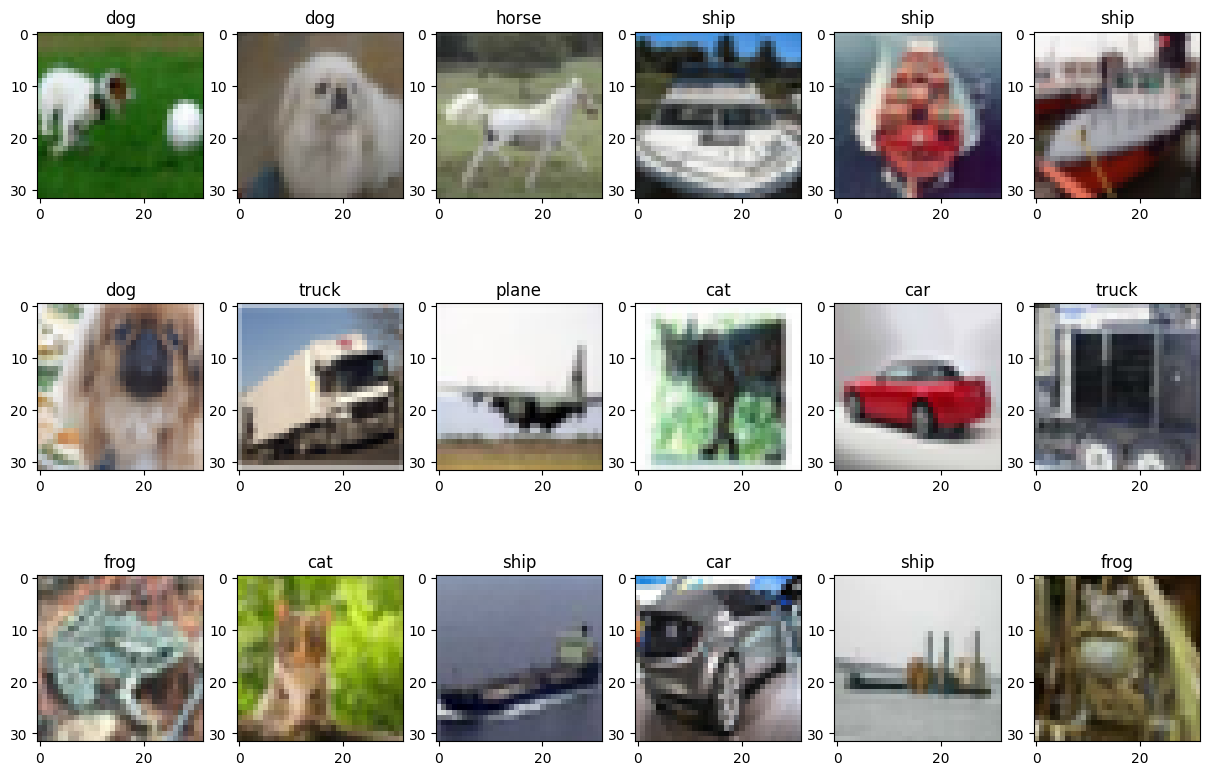

In [ ]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Mapping from class ID to class name
classes = {0:'plane', 1:'car', 2:'bird', 3:'cat', 4:'deer',
           5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}

# Dataset params
num_classes = len(classes)
size = x_train.shape[1]

# Visualize random samples (as a plot with 3x6 samples)
for ii in range(18):
    plt.subplot(3,6,ii+1)
    # Pick a random sample
    idx = np.random.randint(0, len(x_train))
    # Show the image and the label
    plt.imshow(x_train[idx, ...])
    plt.title(classes[int(y_train[idx])])

Compute the class histogram (you can visualize it if you want). Is the dataset balanced?

Hint: You might find [Counter](https://docs.python.org/3/library/collections.html#collections.Counter) tool useful. In any case, it's up to you how you compute the histogram.

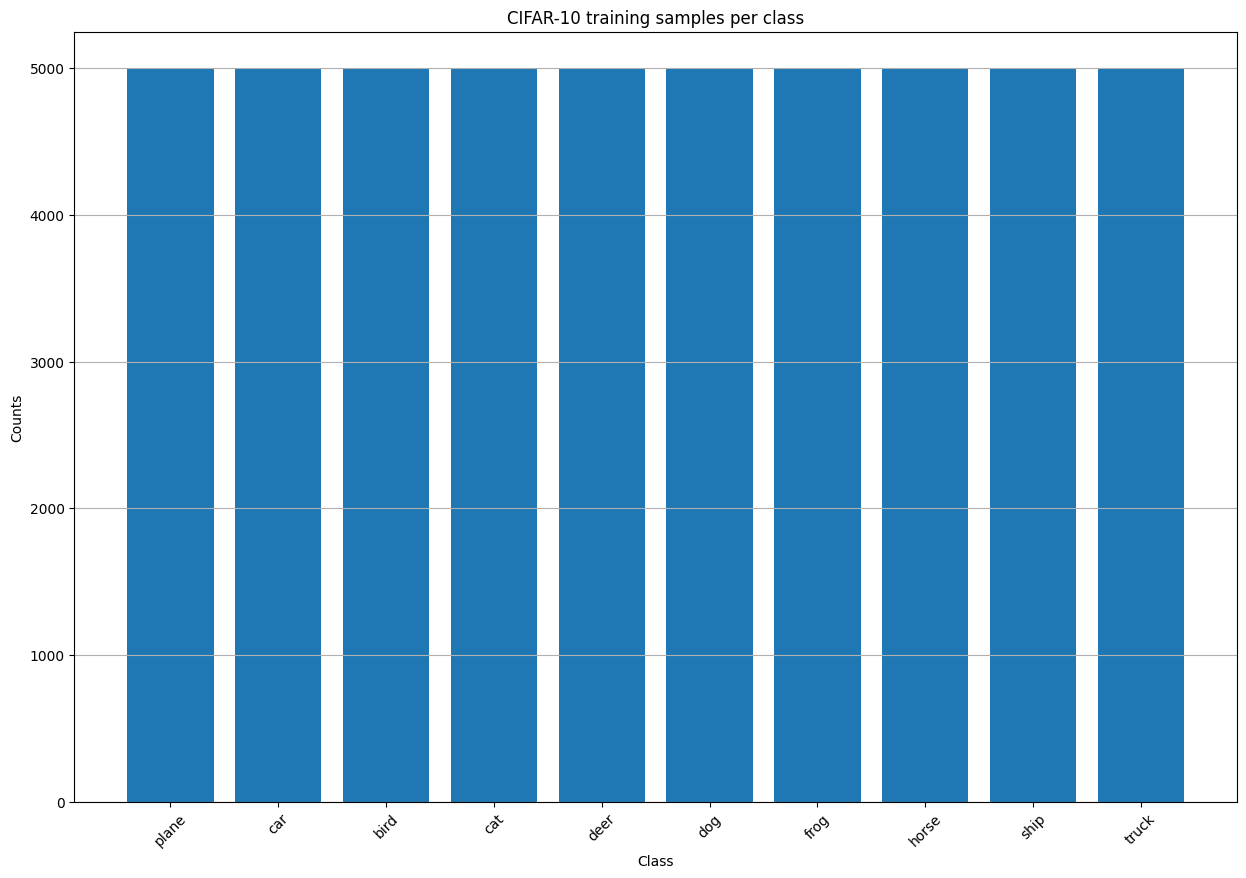

Counter({np.uint8(6): 5000, np.uint8(9): 5000, np.uint8(4): 5000, np.uint8(1): 5000, np.uint8(2): 5000, np.uint8(7): 5000, np.uint8(8): 5000, np.uint8(3): 5000, np.uint8(5): 5000, np.uint8(0): 5000})
Balanced: True


In [ ]:
# Compute the class histogram
from collections import Counter
ids = y_train.flatten()
hist = Counter(ids)
class_ids = sorted(hist.keys())
counts = [hist[class_id] for class_id in class_ids]

plt.bar(class_ids, counts)
plt.xticks(class_ids, [classes[class_id] for class_id in class_ids], rotation=45)
plt.grid(True, axis='y')
plt.xlabel('Class')
plt.ylabel('Counts')
plt.title('CIFAR-10 training samples per class')
plt.show()

print(hist)
print('Balanced:', len(set(counts)) == 1)

### Step 1: Data Preparation

In this step, you'll need to prepare the data for training, i.e., you will have to normalize it and encode the labels as one-hot vectors.

In [ ]:
# Normalization
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

Train set:    50000 samples
Test set:     10000 samples
Sample dims:  (50000, 32, 32, 3)


### Step 2: Building the Classifier

Build the CNN for CIFAR10 classification. For starters, you can use the same network we used in the lesson for the MNIST problem.

In [ ]:
# Build the classifier
def build_classifier(use_augmentation=False):
    inputs = Input(shape=(size, size, 3))
    x = inputs

    if use_augmentation:
        x = tf.keras.Sequential([
            RandomFlip('horizontal'),
            RandomTranslation(0.1, 0.1),
            RandomRotation(0.05),
        ], name='data_augmentation')(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs=inputs, outputs=outputs)


model =build_classifier(use_augmentation=False)

# Show the model
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

### Step 3: Training

Compile the model and train it.

In [ ]:
epochs = 25
batch_size = 128

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
start = time()
history = model.fit(x_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_split=0.2)
print('Training time:', round(time() - start, 2), 'seconds')

Epoch 1/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 265ms/step - accuracy: 0.4171 - loss: 1.6028 - val_accuracy: 0.5243 - val_loss: 1.3372
Epoch 2/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 267ms/step - accuracy: 0.5751 - loss: 1.1919 - val_accuracy: 0.6125 - val_loss: 1.1189
Epoch 3/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 149s 291ms/step - accuracy: 0.6479 - loss: 1.0032 - val_accuracy: 0.6527 - val_loss: 1.0121
Epoch 4/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 271ms/step - accuracy: 0.6925 - loss: 0.8814 - val_accuracy: 0.6848 - val_loss: 0.9184
Epoch 5/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 141s 267ms/step - accuracy: 0.7287 - loss: 0.7832 - val_accuracy: 0.6988 - val_loss: 0.8809
Epoch 6/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 264ms/step - accuracy: 0.7578 - loss: 0.7079 - val_accuracy: 0.6958 - val_loss: 0.9087
Epoch 7/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 266ms/step - accuracy: 0.7761 - loss: 0.6509 - val_accuracy: 0.7092 - val_loss: 0.8702
Epoch 8/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 266ms/step - accuracy: 0.7956 - loss:

Train Acc      0.957099974155426
Validation Acc 0.7071999907493591


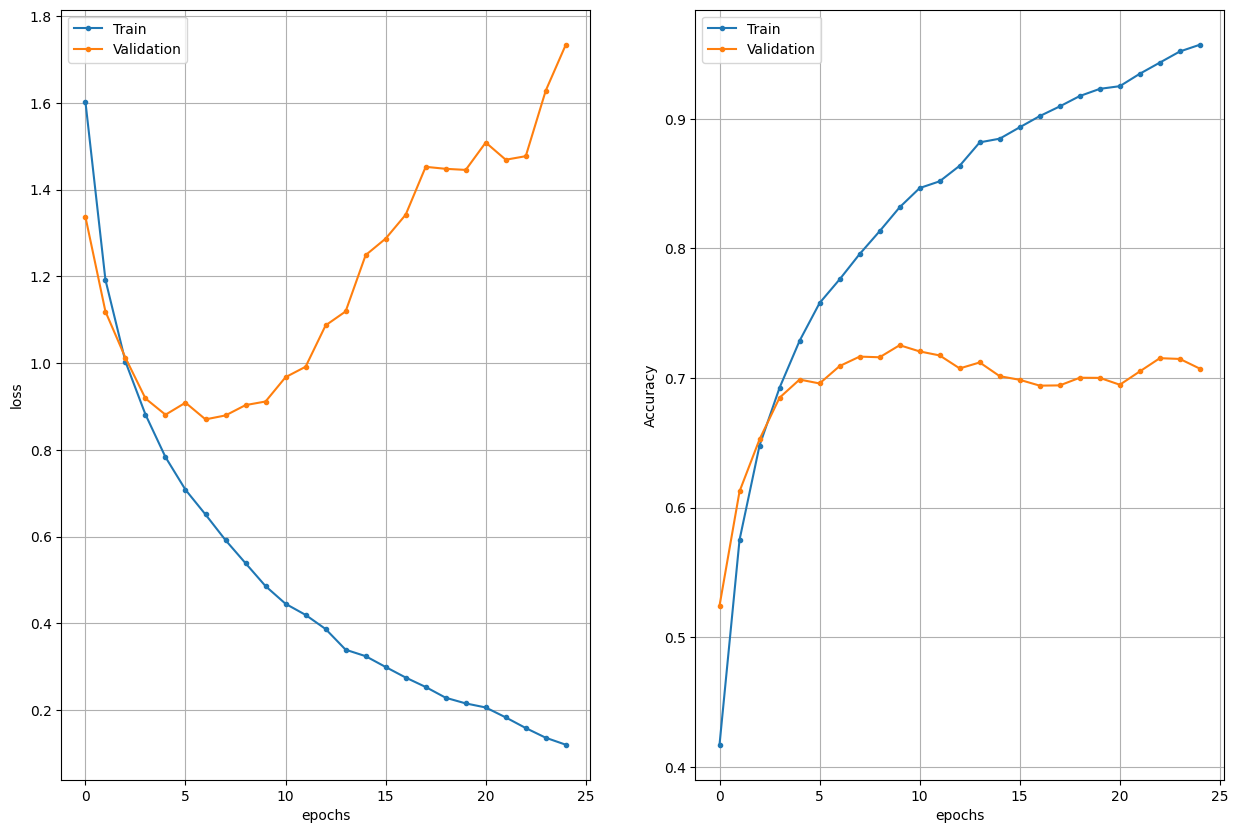

In [ ]:
# Show training history (this cell is complete, nothing to implement here :-) )
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])

### Step 4: Evaluation

In this step, you have to calculate the accuracies and visualize some random samples. For the evaluation, you are going to use the test split from the dataset.

In [ ]:
# Compute the labels and the predictions as sparse values
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(x_test, batch_size=batch_size), axis=1)

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step


In [ ]:
# Compute and print the accuracy for each class
for class_id, class_name in classes.items():
    mask = y_true == class_id
    acc = np.mean(y_pred[mask] == y_true[mask])
    acc = np.mean(y_pred[mask] == y_true[mask])
    print(class_name, acc)

plane 0.753
car 0.795
bird 0.687
cat 0.361
deer 0.538
dog 0.623
frog 0.864
horse 0.775
ship 0.801
truck 0.77


In [ ]:
# Print the overall stats
ev = model.evaluate(x_test, y_test)
print('Test loss  ', ev[0])
print('Test metric', ev[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6967 - loss: 1.7655
Test loss   1.7655259370803833
Test metric 0.6966999769210815


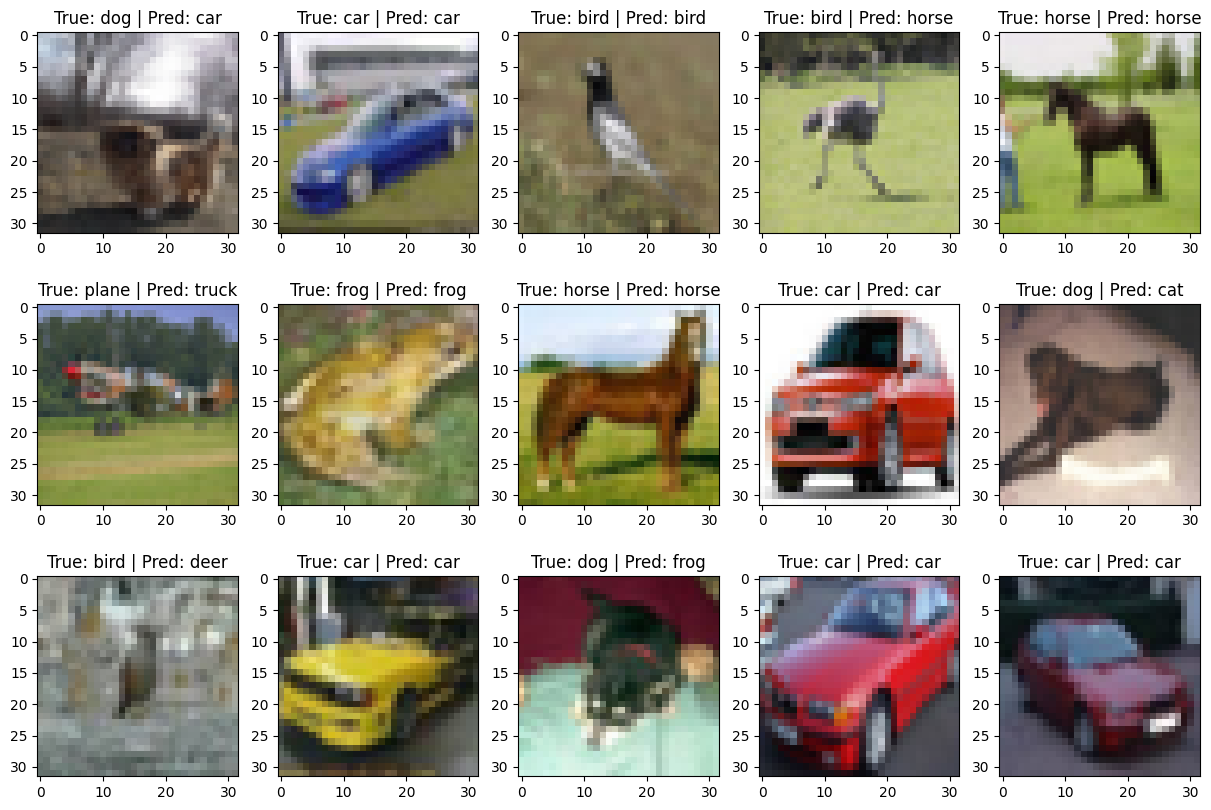

In [ ]:
# Show random samples
for ii in range(15):
    # Pick a random sample
    idx = np.random.randint(0, len(x_test))
    # Show the results
    plt.subplot(3,5,ii+1), plt.imshow(x_test[idx, ...])
    plt.title('True: ' + str(classes[y_true[idx]]) + ' | Pred: ' + str(classes[y_pred[idx]]))

### Questions
* What is the overall accuracy of the classifier?

The overall test accuracy of the classifier is about **69.7%**.

The printed test metric is:

`Test metric 0.6966999769210815`

* What modifications would you do in order to improve the classification accuracy?

To improve the classification accuracy, I would try adding **data augmentation**, **dropout**, and **batch normalization**. I would also consider using a deeper CNN, early stopping, and learning-rate scheduling.

The current model seems to overfit because the training accuracy is about **95.7%**, while the validation accuracy is only about **70.7%**. Therefore, regularization techniques such as data augmentation and dropout could help the model generalize better.

* Make **one** modification (that you think can help) and train the classifier again. Does the accuracy improve?

I would add **data augmentation** as one modification. For CIFAR-10, random horizontal flips, small translations, and small rotations can help because objects may appear in slightly different positions and orientations.

After training the classifier again with data augmentation, I would compare the new test accuracy with the original test accuracy of **69.7%**. If the new test accuracy is higher than **69.7%**, then the modification improved the classifier. If it is lower or similar, then the modification did not improve the result significantly.